# Tienda de Ropa

In [33]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from PIL import Image

In [62]:
# Descargar el dataset de Fashion Mnist
datos, metadatos = tfds.load('fashion_mnist', as_supervised = True, with_info = True)

### Parametros as_supervised y with_info 
- as_supervised: Formatea el conjunto de datos a un par de tuplas (entrada, etiqueta).
- with_info: Sirve para obtener los metadatos detallados del dataset cargado.

In [63]:
# Imprimir los metadatos 
metadatos

tfds.core.DatasetInfo(
    name='fashion_mnist',
    full_name='fashion_mnist/3.0.1',
    description="""
    Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.
    """,
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    data_dir='/home/miguel/tensorflow_datasets/fashion_mnist/3.0.1',
    file_format=tfrecord,
    download_size=29.45 MiB,
    dataset_size=36.42 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{DBLP:journa

In [64]:
# Ordenar cada conjunto de datos en las variables correspondientes 
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

In [65]:
# Asignar los nombres de las categorías (incluidas en el set) a una variable y mostrarlas. 
nombres_clases = metadatos.features['label'].names
nombres_clases

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [66]:
# Normalizar los datos
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes /= 255 # Pasa de 0-255 a 0-1
    return imagenes, etiquetas

datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

# Guardar los datos en caché y no utilizar espacio en disco.
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

### ¿Para que se utiliza la función map()?
Es una funcio que se aplica a cada elemento iterable (en este caso tupla) para evitar usar un bucle for.

W0000 00:00:1773102469.193463   62027 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
W0000 00:00:1773102469.193538   62027 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


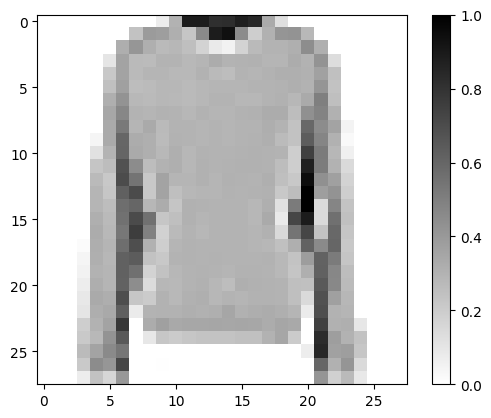

In [67]:
# Mostrar una imagen de los datos de prueba 
for imagen, etiqueta in datos_entrenamiento.take(1):
    break

img = imagen.numpy().reshape((28, 28)) # Redimensionar los pixeles

# Dibujar la imagen 
plt.figure()
plt.imshow(img, cmap = plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

W0000 00:00:1773102472.843786   62120 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
W0000 00:00:1773102472.844012   62120 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


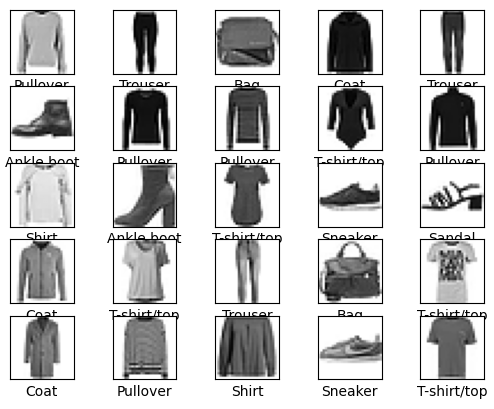

In [68]:
# Mostrar una imagen por cada categoria con su etiqueta
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)): 
    imagen = imagen.numpy().reshape((28, 28))
    
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imagen, cmap = plt.cm.binary)
    plt.xlabel(nombres_clases[etiqueta])
plt.show()


In [69]:
# Creación del modelo
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape = (28, 28, 1)), # Blanco y negro
    tf.keras.layers.Dense(50, activation = tf.nn.relu),
    tf.keras.layers.Dense(50, activation = tf.nn.relu),
    tf.keras.layers.Dense(10, activation = tf.nn.softmax), # Para redes de clasificacion
])

In [70]:
# Compilar el modelo con el algoritmo de optimizacion "Adam"
modelo.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = ['accuracy']
)

In [71]:
# Dividir por lotes

TAMANO_LOTE = 32

# Los numeros de datos en entrenamiento y pruebas (60K y 10K)

nun_ej_entrenamiento = metadatos.splits['train'].num_examples
num_ej_pruebas = metadatos.splits['test'].num_examples

print("Numero de datos de ejemplo para entrenamiento: ", nun_ej_entrenamiento)
print("Numero de datos de ejemplo para pruebas: ", num_ej_pruebas)

# Ajustar las propiedades de los datos de entrenamiento y prueba.

datos_entrenamiento = datos_entrenamiento.repeat().shuffle(nun_ej_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

Numero de datos de ejemplo para entrenamiento:  60000
Numero de datos de ejemplo para pruebas:  10000


In [72]:
# Entrenar el modelo
historial = modelo.fit(datos_entrenamiento, epochs = 5, steps_per_epoch = math.ceil(nun_ej_entrenamiento/TAMANO_LOTE))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8156 - loss: 0.5187
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8605 - loss: 0.3874
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8722 - loss: 0.3528
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8798 - loss: 0.3283
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8845 - loss: 0.3175


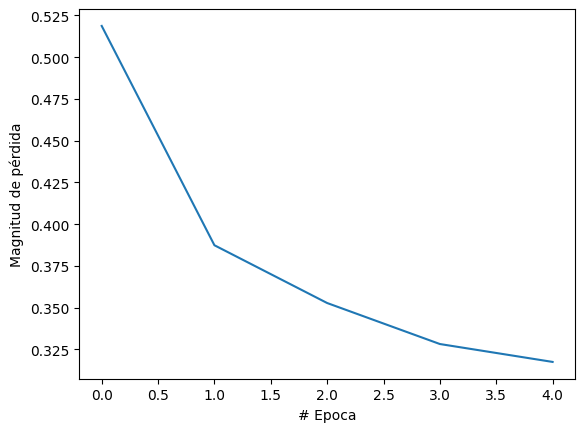

In [73]:
# Mostrar los datos de la función de perdida
plt.xlabel('# Epoca')
plt.ylabel('Magnitud de pérdida')
plt.plot(historial.history['loss'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


W0000 00:00:1773103149.512755   69327 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
W0000 00:00:1773103149.512917   69327 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediccion: Bag


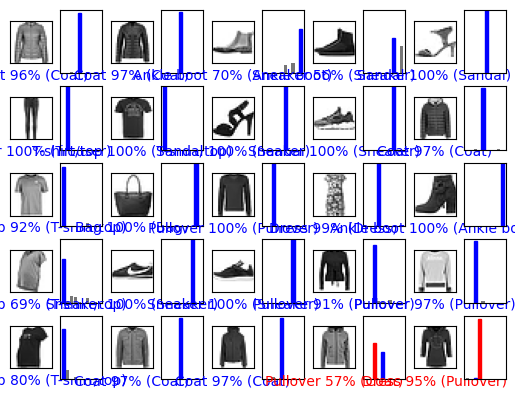

In [79]:
'''
Realizar predicciones. Imprimir 25 imágenes del set de prueba y realice la predicción de la categoría a la que pertenece cada una de 
esas imágenes
'''

# Crear una cuadricula on varias predicciones, y marcar si fue correcta (azul) o incorrecta (roja)
for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba.numpy()

predicciones = modelo.predict(imagenes_prueba)

def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
    arr_predicciones, etiqueta_real, img = arr_predicciones[i], etiquetas_reales[i], imagenes[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img[..., 0], cmap = plt.cm.binary)

    etiqueta_prediccion = np.argmax(arr_predicciones)
    if etiqueta_prediccion == etiqueta_real:
        color = 'blue'
    else:
        color = 'red'
    
    plt.xlabel("{} {:2.0f}% ({})".format(nombres_clases[etiqueta_prediccion], 100*np.max(arr_predicciones), nombres_clases[etiqueta_real]), color = color)

def graficar_valor_arreglo(i, arr_prediciones, etiqueta_real): 
    arr_prediciones, etiqueta_real = arr_prediciones[i], etiqueta_real[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    grafica = plt.bar(range(10), arr_prediciones, color = '#777777')
    plt.ylim([0, 1])
    etiqueta_prediccion = np.argmax(arr_prediciones)

    grafica[etiqueta_prediccion].set_color('red')
    grafica[etiqueta_real].set_color('blue')

filas = 5
columnas = 5
num_imagenes = filas*columnas
for i in range(num_imagenes):
    plt.subplot(filas, 2*columnas, 2*i+1)
    graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
    plt.subplot(filas, 2*columnas, 2*i+2)
    graficar_valor_arreglo(i, predicciones, etiquetas_prueba)

# Realizar la prediccion de una imagen 
imagen = Image.open('./tenis_nike.png').resize((28, 28)) #imagenes_prueba[24]
imagen = np.array([imagen])
modelo.save('Tienda_de_ropa.h5')
prediccion = modelo.predict(imagen)

print("Prediccion: " + nombres_clases[np.argmax(prediccion[0])])

### Formato h5
Es un formato de archivo basado en el estándar Hierarchical Data Format versión 5 (HDF5). Sirve para almacenar de manera estructurada y optimizada modelos de machine learning, incluyendo: Su arquitectura, pesos y configuraciones; todo esto, dentro de un archivo binario.